# MAPPO Evaluation & Rendering

This runs the trained MAPPO policy with the patrolling zoo.

In [1]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.render.render_pettingzoo import main
import os
import yaml
os.environ["WANDB__SERVICE_WAIT"] = "300"

## Configuration

In [ ]:
# Set the run directory.
model_dir = "/data/group/mas/qmas/results/isru_v0/mappo/isru-hybridObs-e200-r20rand-h5-512x4/wandb/run-20250827_223519-z3kio5vl/files"

In [3]:
# Load arguments from the config file.
config_file = os.path.join(model_dir, "config.yaml")
args = yaml.load(open(config_file), Loader=yaml.FullLoader)

def wrap_arg_val(val):
    return {"value": val}

# Set required render-specific arguments. Do not change these!
args["use_wandb"] = wrap_arg_val(False)
args["use_render"] = wrap_arg_val(True)
args["model_dir"] = wrap_arg_val(model_dir)
args["cuda"] = wrap_arg_val(True)
# args["cuda_idx"] = wrap_arg_val(0)

In [4]:
# Feel free to change these arguments or add additional arguments here.

args["render_episodes"] = wrap_arg_val(1)
args["episode_length"] = wrap_arg_val(200)
args["max_cycles"] = args["episode_length"]
args["seed"] = wrap_arg_val(0)

# args["observation_probability"] = wrap_arg_val(0.5)
# args["diffusion_autoregression_steps"] = wrap_arg_val(4)
args["prediction_disable"] = wrap_arg_val(True)

In [5]:
# Convert arguments to the appropriate format.
arglist = []
for key, value in args.items():
    if type(value) == dict and "value" in value and not key.startswith("_"):
        v = value["value"]
        if v == None:
            continue
        if type(v) == bool:
            if v:
                arglist.append(f"--{key}")
            else:
                arglist.append(f"--no-{key}")
        else:
            arglist.append(f"--{key}")
            arglist.append(str(v))

## Perform Rendering

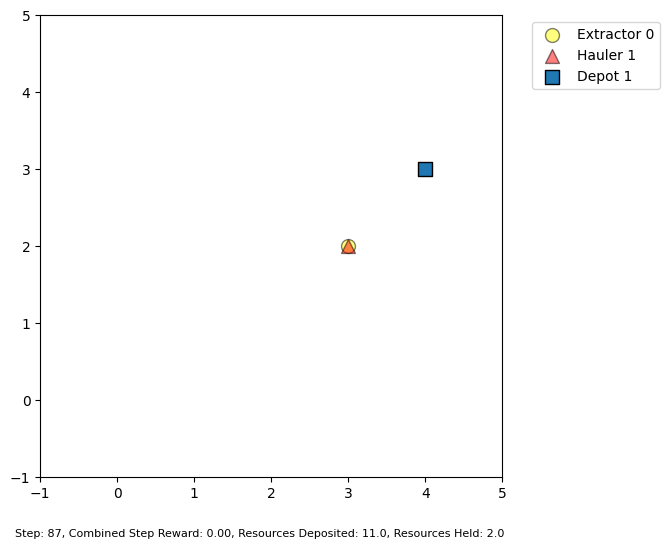

Step 0 - FPS: 7.36 (excluding render) - Reward Total: 30556.50


In [6]:
main(arglist)